<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/olympic_data_analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **OLYMPIC DATA ANALYST PROJECT (1976-2008)**

**IMPORT LIBRARIES**

In [ ]:
#STEP 1:- IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
import warnings
warnings.filterwarnings("ignore")
from IPython.display import Markdown
import plotly.express as px

**LOAD DATASET**

In [ ]:
# STEP 2:- LOAD DATASET
data=pd.read_csv("Summer-Olympic-medals-1976-to-2008.csv",encoding="latin1")
print("DATASET LOADED SUCCESSFULLY ")
print("SHAPE OF DATASET",data.shape)
print("\nPreview:")
print(data.head())

DATASET LOADED SUCCESSFULLY 
SHAPE OF DATASET (15433, 12)

Preview:
       City    Year     Sport Discipline           Event  \
0  Montreal  1976.0  Aquatics     Diving  3m springboard   
1  Montreal  1976.0  Aquatics     Diving  3m springboard   
2  Montreal  1976.0  Aquatics     Diving  3m springboard   
3  Montreal  1976.0  Aquatics     Diving  3m springboard   
4  Montreal  1976.0  Aquatics     Diving    10m platform   

                    Athlete Gender Country_Code        Country Event_gender  \
0           KÖHLER, Christa  Women          GDR   East Germany            W   
1       KOSENKOV, Aleksandr    Men          URS   Soviet Union            M   
2      BOGGS, Philip George    Men          USA  United States            M   
3  CAGNOTTO, Giorgio Franco    Men          ITA          Italy            M   
4    WILSON, Deborah Keplar  Women          USA  United States            W   

    Medal  Count  
0  Silver    NaN  
1  Bronze    NaN  
2    Gold    NaN  
3  Silver    NaN  
4

**DATA CLEANING**

In [ ]:
#STEP 3:- DATA CLEANING
print("\nChecking for missing values:\n")
print(data.isnull().sum())

data.dropna(how='all', inplace=True)
data['Year'] = data['Year'].astype(str).str.replace('.0', '', regex=False).astype(int)

if 'Country_Code' in data.columns:
    data.drop('Country_Code', axis=1, inplace=True)
if 'Event_gender' in data.columns:
    data.drop('Event_gender', axis=1, inplace=True)

print("\n✅ Cleaned Data:")
print(data.info())


Checking for missing values:

City              117
Year              117
Sport             117
Discipline        117
Event             117
Athlete           117
Gender            117
Country_Code      117
Country           117
Event_gender      117
Medal             117
Count           15433
dtype: int64

✅ Cleaned Data:
<class 'pandas.core.frame.DataFrame'>
Index: 15316 entries, 0 to 15432
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        15316 non-null  object 
 1   Year        15316 non-null  int64  
 2   Sport       15316 non-null  object 
 3   Discipline  15316 non-null  object 
 4   Event       15316 non-null  object 
 5   Athlete     15316 non-null  object 
 6   Gender      15316 non-null  object 
 7   Country     15316 non-null  object 
 8   Medal       15316 non-null  object 
 9   Count       0 non-null      float64
dtypes: float64(1), int64(1), object(8)
memory usage: 1.3+ MB
None


**EXPLORATORY DATA ANALYSIS (EDA)**


   CITIES THAT HOSTED THE OLYMPICS (1976–2008)

              City  Year
0         Montreal  1976
1422        Moscow  1980
2809   Los Angeles  1984
4268         Seoul  1988
5814     Barcelona  1992
7519       Atlanta  1996
9378        Sydney  2000
11393       Athens  2004
13391      Beijing  2008


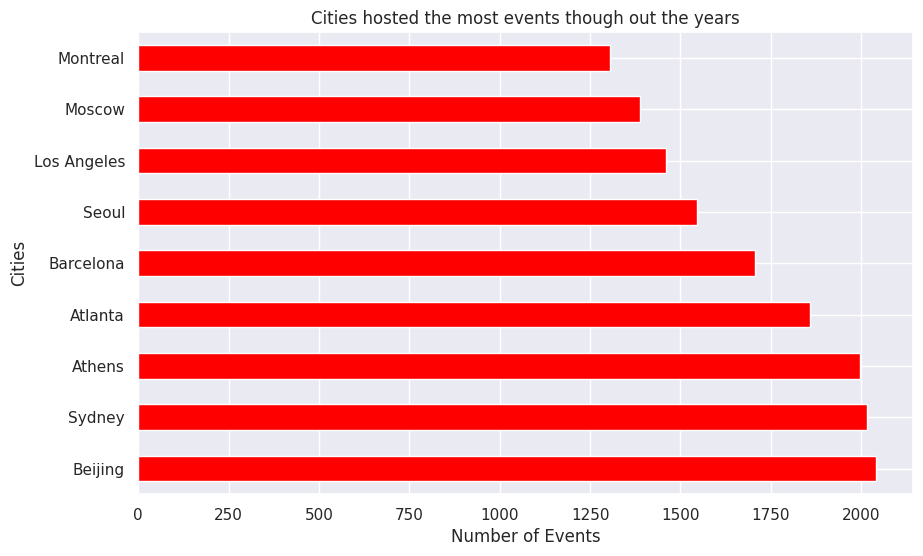

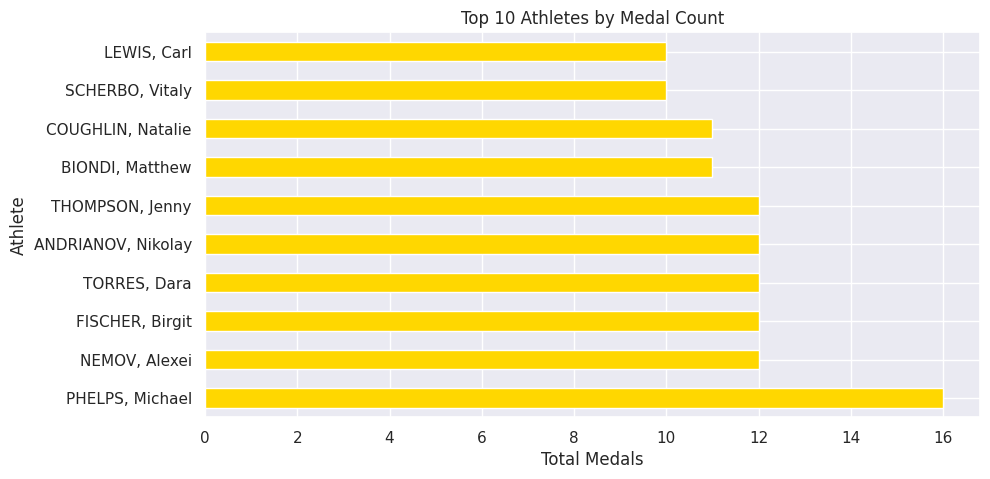

**Top Athlete by Total Medals: _PHELPS, Michael_**

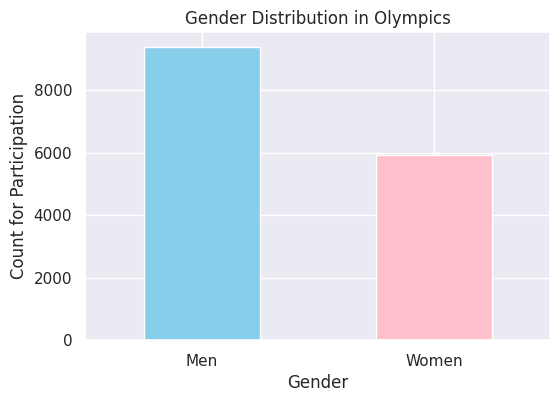

In [ ]:
#STEP 4:- EXPLORATORY DATA ANALYSIS (EDA)
#4.1- CITIES THAT HOSTED OLYMPICS
city_counts = data[['City', 'Year']].drop_duplicates('Year')
print("\n" + "="*55)
print("   CITIES THAT HOSTED THE OLYMPICS (1976–2008)")
print("="*55 + "\n")
print(city_counts)

#4.2- WHICH CITIES HOSTED THE MOST EVENTS
plt.figure(figsize=(10,6))
data['City'].value_counts().plot(kind="barh",color="red" )
plt.title("Cities hosted the most events though out the years")
plt.xlabel("Number of Events")
plt.ylabel("Cities")
plt.xticks(rotation=0)
plt.show()

#4.3- WHICH ATHLETE WON THE MOST MEDALS
athlete_medals = data['Athlete'].value_counts().head(10)
plt.figure(figsize=(10,5))
athlete_medals.plot(kind='barh', color='gold')
plt.title("Top 10 Athletes by Medal Count")
plt.xlabel("Total Medals")
plt.ylabel("Athlete")
plt.show()

print("\n" + "="*55)
display(Markdown(f"**Top Athlete by Total Medals: _{athlete_medals.index[0]}_**"))
print("="*55 + "\n")

#4.4- GENDER DISTRIBUTION
gender_dist = data['Gender'].value_counts()
plt.figure(figsize=(6,4))
gender_dist.plot(kind='bar', color=['skyblue', 'pink'])
plt.title("Gender Distribution in Olympics")
plt.xlabel("Gender")
plt.ylabel("Count for Participation")
plt.xticks(rotation=0)
plt.show()

#4.5- TOTAL MEDAL PER COUNTRY

#4.5.1 DATA
# Total medals per country
total_medals = data['Country'].value_counts().reset_index()
total_medals.columns = ['Country', 'Total_Medals']

# Gold / Silver / Bronze medals per country
gold_medals = data[data['Medal'] == 'Gold']['Country'].value_counts().reset_index()
gold_medals.columns = ['Country', 'Gold_Medals']

silver_medals = data[data['Medal'] == 'Silver']['Country'].value_counts().reset_index()
silver_medals.columns = ['Country', 'Silver_Medals']

bronze_medals = data[data['Medal'] == 'Bronze']['Country'].value_counts().reset_index()
bronze_medals.columns = ['Country', 'Bronze_Medals']

# Medals by Year & Country (for animation)
yearly_medals = data.groupby(['Year', 'Country']).size().reset_index(name='Medal_Count')

#4.5.2 TOTAL MEDALS
fig = px.choropleth(
    total_medals,
    locations="Country",
    locationmode="country names",
    color="Total_Medals",
    title=" Total Olympic Medals by Country (1976–2008)",
    color_continuous_scale="Oranges",
)

fig.show()

#4.5.3 GOLD MEDALS MAP
fig = px.choropleth(
    gold_medals,
    locations="Country",
    locationmode="country names",
    color="Gold_Medals",
    title=" Gold Medal Distribution (1976–2008)",
    color_continuous_scale="YlOrBr"
)

fig.show()

#4.5.4 SILVER MEDALS MAP
fig = px.choropleth(
    silver_medals,
    locations="Country",
    locationmode="country names",
    color="Silver_Medals",
    title=" Silver Medal Distribution (1976–2008)",
    color_continuous_scale="Greys"
)

fig.show()

#4.5.5 BRONZE MEDALS MAP
fig = px.choropleth(
    bronze_medals,
    locations="Country",
    locationmode="country names",
    color="Bronze_Medals",
    title=" Bronze Medal Distribution (1976–2008)",
    color_continuous_scale="Plasma" # Changed from "Copper" to "Plasma"
)

fig.show()

#4.5.6 MEDALS OVER YEARS
fig = px.choropleth(
    yearly_medals,
    locations="Country",
    locationmode="country names",
    color="Medal_Count",
    hover_name="Country",
    animation_frame="Year",
    title="Olympic Medals Over the Years (1976–2008)",
    color_continuous_scale="Plasma"
)

fig.show()

#4.5.7 COMBINED MAP
combined = total_medals.merge(gold_medals, on="Country", how="left") \
                       .merge(silver_medals, on="Country", how="left") \
                       .merge(bronze_medals, on="Country", how="left")

combined.fillna(0, inplace=True)
combined.head()

#4.6 TREND OF MEDALS OVER THE YEARS


country_medals = data['Country'].value_counts().reset_index()
country_medals.columns = ['Country', 'Medals']

fig = px.choropleth(
    country_medals,
    locations="Country",
    locationmode="country names",
    color="Medals",
    color_continuous_scale="Viridis",
    title="World Map: Medal Distribution"
)

fig.show()




**KEY INSIGHT**


In [ ]:
#STEP5:- KEY INSIGHT

# STEP 5:- KEY INSIGHTS FROM ANALYSIS

print("\n" + "="*70)
print("          KEY INSIGHTS FROM OLYMPICS DATA (1976–2008)")
print("="*70 + "\n")

# Insight 1 – Top Country
top_country = data['Country'].value_counts().idxmax()
top_country_medals = data['Country'].value_counts().max()

print("1️⃣  COUNTRY PERFORMANCE")
print(f"- {top_country} secured the highest medal count ({top_country_medals} medals).")
print("- A small number of countries dominate the majority of medals.\n")

# Insight 2 – Gender Distribution
gender_dist = data['Gender'].value_counts()
top_gender = gender_dist.idxmax()

print("2️⃣  GENDER PARTICIPATION")
print(f"- {top_gender} athletes have participated more in the tournament.")
print("- Female participation, although lower, shows steady improvement.\n")

# Insight 3 – Top Athlete
athlete_medals = data['Athlete'].value_counts()
top_athlete = athlete_medals.idxmax()
top_athlete_count = athlete_medals.max()

print("3️⃣  ATHLETE PERFORMANCE")
print(f"- {top_athlete} is the most decorated athlete with {top_athlete_count} medals.")
print("- Very few athletes win medals consistently across multiple years.\n")

# Insight 4 – Hosting Cities
city_counts = data[['City','Year']].drop_duplicates('Year')
most_hosted_city = data['City'].value_counts().idxmax()
host_count = data['City'].value_counts().max()

print("4️⃣  HOSTING CITY OBSERVATIONS")
print(f"- {most_hosted_city} hosted the most Olympic events ({host_count} times).")
print("- Hosting duties rotate widely among global cities.\n")

# Insight 5 – Medal Trends Over Years
medals_by_year = data.groupby("Year")['Medal'].count()
peak_year = medals_by_year.idxmax()
peak_medals = medals_by_year.max()

print("5️⃣  YEARLY MEDAL TREND")
print(f"- Highest number of medals were awarded in {peak_year} ({peak_medals} medals).")
print("- Medal counts show fluctuations based on participation and event count.\n")

# Insight 6 – Geographic Insights
print("6️⃣  GEOGRAPHICAL DISTRIBUTION")
print("- North America, Europe, and parts of Asia lead the medal tally.")
print("- Developing nations show lower medal counts due to resource and training gaps.\n")

print("="*70)
print("                        ✔ END OF KEY INSIGHTS")
print("="*70 + "\n")




          KEY INSIGHTS FROM OLYMPICS DATA (1976–2008)

1️⃣  COUNTRY PERFORMANCE
- United States secured the highest medal count (1992 medals).
- A small number of countries dominate the majority of medals.

2️⃣  GENDER PARTICIPATION
- Men athletes have participated more in the tournament.
- Female participation, although lower, shows steady improvement.

3️⃣  ATHLETE PERFORMANCE
- PHELPS, Michael is the most decorated athlete with 16 medals.
- Very few athletes win medals consistently across multiple years.

4️⃣  HOSTING CITY OBSERVATIONS
- Beijing hosted the most Olympic events (2042 times).
- Hosting duties rotate widely among global cities.

5️⃣  YEARLY MEDAL TREND
- Highest number of medals were awarded in 2008 (2042 medals).
- Medal counts show fluctuations based on participation and event count.

6️⃣  GEOGRAPHICAL DISTRIBUTION
- North America, Europe, and parts of Asia lead the medal tally.
- Developing nations show lower medal counts due to resource and training gaps.

        

**CONCLUSION**


In [ ]:
print("\n" + "="*70)
print("                            CONCLUSION")
print("="*70)

print("""
The analysis of Summer Olympics data (1976–2008) shows that:
• Developed countries dominate total medal counts.
• Male participation is still higher than female participation.
• A few exceptional athletes make a large impact on medal tallies.
• Certain cities appear repeatedly as Olympic hosts.
• Total medals fluctuate over the years based on event frequency.
• Interactive world maps highlight strong global differences in performance.

This project demonstrates how data analytics reveals performance gaps,
participation trends, and global patterns in international sporting events.
""")

print("="*70)



                            CONCLUSION

The analysis of Summer Olympics data (1976–2008) shows that:
• Developed countries dominate total medal counts.
• Male participation is still higher than female participation.
• A few exceptional athletes make a large impact on medal tallies.
• Certain cities appear repeatedly as Olympic hosts.
• Total medals fluctuate over the years based on event frequency.
• Interactive world maps highlight strong global differences in performance.

This project demonstrates how data analytics reveals performance gaps,
participation trends, and global patterns in international sporting events.

